In [1]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import Ball, Stick, Zeppelin, Dti, BallStick, Ball2Stick


In [2]:
bvals = jnp.linspace(0, 3000, 100)
bvecs = np.random.randn(100, 3)
bvecs = bvecs / np.linalg.norm(bvecs, axis=1)[:, None]


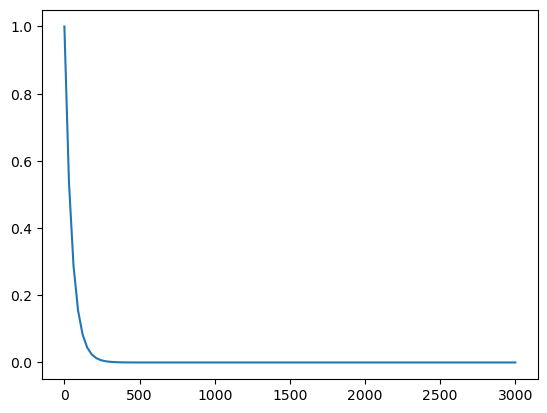

In [3]:
theta = np.random.randn(Ball.theta_dim)
ball = Ball.from_theta(theta)


signal = ball.signal(bvals, bvecs)

plt.plot(bvals, signal)

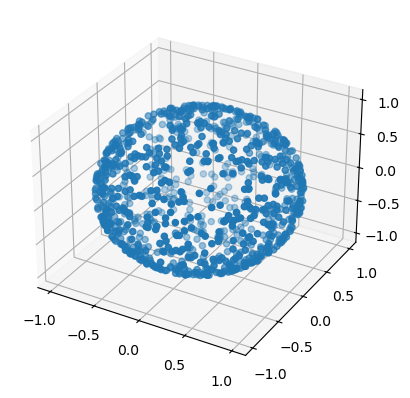

In [4]:
directions = jax.vmap(ball.fod_sample)(jax.random.split(jax.random.key(0), 1000))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(directions[:, 0], directions[:, 1], directions[:, 2])

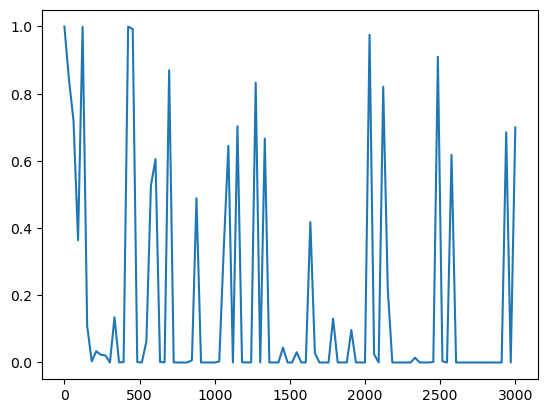

In [5]:
theta = np.random.randn(Stick.theta_dim)
stick = Stick.from_theta(theta)


signal = stick.signal(bvals, bvecs)

plt.plot(bvals, signal)

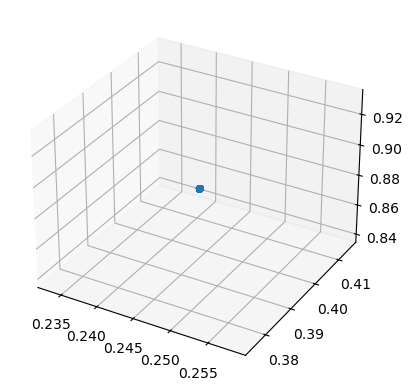

In [6]:
directions = jax.vmap(stick.fod_sample)(jax.random.split(jax.random.key(0), 1000))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(directions[:, 0], directions[:, 1], directions[:, 2])

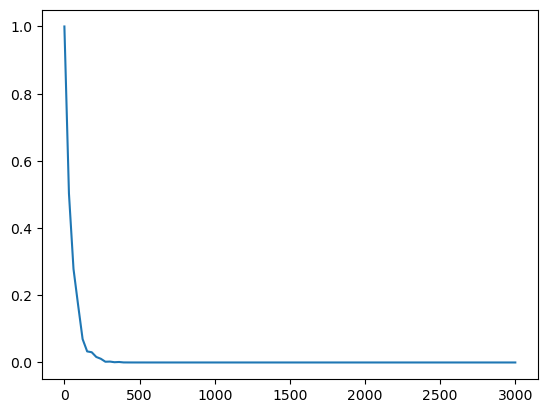

In [7]:
theta = np.random.randn(Zeppelin.theta_dim)
zep = Zeppelin.from_theta(theta)


signal = zep.signal(bvals, bvecs)

plt.plot(bvals, signal)

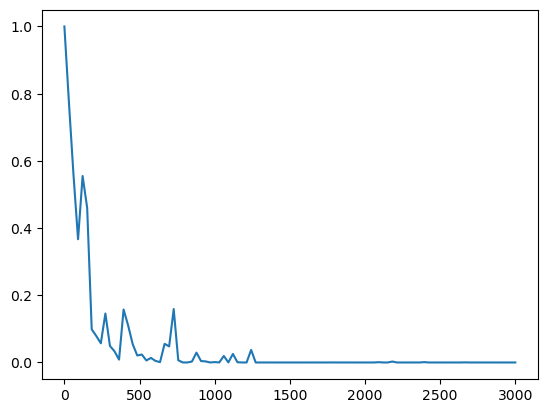

In [8]:
theta = np.random.randn(Dti.theta_dim)
dti = Dti.from_theta(theta)


signal = dti.signal(bvals, bvecs)

plt.plot(bvals, signal)

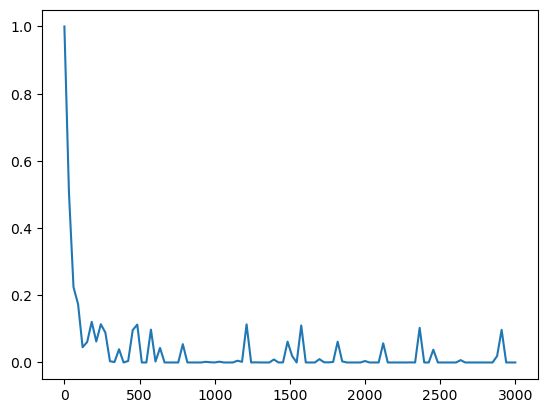

In [9]:
ball_stick = BallStick.from_theta(np.random.randn(BallStick.theta_dim))

signal = ball_stick.signal(bvals, bvecs, None)

plt.plot(bvals, signal)

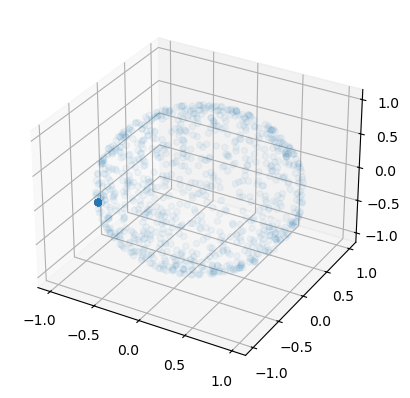

In [10]:
directions = jax.vmap(ball_stick.fod_sample)(jax.random.split(jax.random.key(0), 1000))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(directions[:, 0], directions[:, 1], directions[:, 2], alpha=0.05)

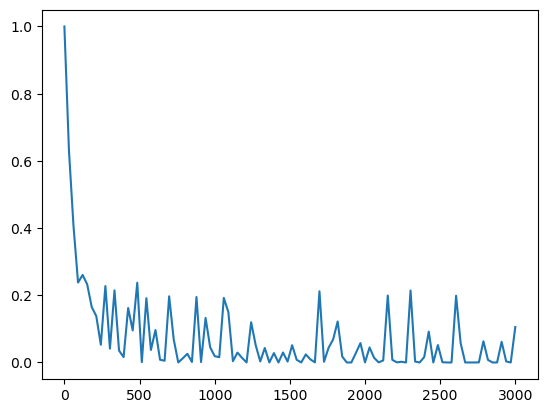

In [13]:
ball_stick = Ball2Stick.from_theta(np.random.randn(Ball2Stick.theta_dim))

signal = ball_stick.signal(bvals, bvecs, None)

plt.plot(bvals, signal)

In [13]:
jax.tree_flatten(ball)

/tmp/ipykernel_11530/2654855091.py:1: DeprecationWarning: jax.tree_flatten is deprecated: use jax.tree.flatten (jax v0.4.25 or newer) or jax.tree_util.tree_flatten (any JAX version).
  jax.tree_flatten(ball)


([Array([1.3251603], dtype=float32)],
 PyTreeDef(CustomNode(Ball[(<class 'dmri.simulators.local_signal_models.gaussian_models.Ball'>,)], [*])))